# 02 - Physics-Inspired Feature Engineering Analysis

## Objective

This notebook converts the EDA findings into a clear feature engineering strategy for the Boom Challenge.

The goal is to create physically meaningful variables that help the model generalize beyond the training distribution.

Main ideas:

- transferred energy matters more than raw energy alone;
- gravity strongly controls ejecta travel distance;
- material strength and porosity control fragmentation behavior;
- atmosphere and shape factor act as drag-related proxies;
- regime indicators can help tree-based models capture threshold effects.

## 1. Imports and Project Paths

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_regression

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FORWARD_DIR = PROJECT_ROOT / "data" / "raw" / "forward_prediction"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Forward data:", FORWARD_DIR)
print("Processed output:", PROCESSED_DIR)
print("Reports output:", REPORTS_DIR)

Project root: /home/alouiyaz/projects/boom-challenge-ejecta-prediction
Forward data: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/raw/forward_prediction
Processed output: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/processed
Reports output: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/reports


## 2. Load Data

In [2]:
input_cols = [
    "energy", "angle_rad", "coupling", "strength",
    "porosity", "gravity", "atmosphere", "shape_factor",
]

target_cols = [
    "P80", "fines_frac", "oversize_frac",
    "R95", "R50_fines", "R50_oversize",
]

fragmentation_targets = ["P80", "fines_frac", "oversize_frac"]
distance_targets = ["R95", "R50_fines", "R50_oversize"]

train = pd.read_csv(FORWARD_DIR / "train.csv")
labels = pd.read_csv(FORWARD_DIR / "train_labels.csv")
test = pd.read_csv(FORWARD_DIR / "test.csv")

X_raw_train = train[input_cols].copy()
X_raw_test = test[input_cols].copy()
labels = labels[target_cols].copy()

print("Train inputs:", X_raw_train.shape)
print("Train labels:", labels.shape)
print("Test inputs:", X_raw_test.shape)

display(X_raw_train.head())
display(labels.head())

Train inputs: (2930, 8)
Train labels: (2930, 6)
Test inputs: (492, 8)


,energy,angle_rad,coupling,strength,porosity,gravity,atmosphere,shape_factor
0,3.826405,0.818303,0.861258,1.305809,0.337215,3.71,0.781263,0.784028
1,2.828754,1.193036,0.561245,3.494501,0.058029,1.62,0.136205,0.922737
2,3.068907,0.605872,0.948860,1.366386,0.315632,3.71,0.774704,0.954922
3,2.700574,1.073708,0.713705,3.599419,0.033062,1.62,0.144204,0.932911
4,3.484022,0.863568,1.237205,1.996742,0.278207,9.81,0.414620,1.260855


,P80,fines_frac,oversize_frac,R95,R50_fines,R50_oversize
0,76.972350,0.184728,0.016671,198.938699,175.527939,76.235779
1,269.057465,0.000622,0.916734,239.268477,447.157838,141.894047
2,104.070923,0.070343,0.094438,192.986417,189.286407,84.235774
3,257.618403,0.001026,0.880122,289.289693,500.000028,169.866473
4,111.717167,0.058576,0.136166,94.229304,97.614864,42.928393


## 3. Feature Engineering Logic

The EDA suggested two main target families:

- fragmentation targets: P80, fines_frac, oversize_frac;
- distance targets: R95, R50_fines, R50_oversize.

This motivates separate feature groups for material fragmentation and travel distance.

## 4. Physics-Inspired Feature Function

The function below creates the full engineered feature matrix used later by the modeling notebooks.

In [3]:
def add_physics_features(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    eps = 1e-9

    # Energy transfer
    X["effective_energy"] = X["energy"] * X["coupling"]
    X["log_energy"] = np.log1p(X["energy"])
    X["log_effective_energy"] = np.log1p(X["effective_energy"])

    # Angle decomposition
    X["sin_angle"] = np.sin(X["angle_rad"])
    X["cos_angle"] = np.cos(X["angle_rad"])
    X["tan_angle"] = np.tan(X["angle_rad"])
    X["horizontal_energy"] = X["effective_energy"] * X["cos_angle"]
    X["vertical_energy"] = X["effective_energy"] * X["sin_angle"]
    X["vertical_horizontal_ratio"] = X["vertical_energy"] / (X["horizontal_energy"] + eps)

    # Material resistance and fragmentation
    X["energy_per_strength"] = X["energy"] / (X["strength"] + eps)
    X["effective_energy_per_strength"] = X["effective_energy"] / (X["strength"] + eps)
    X["material_resistance_index"] = X["strength"] * (1 - X["porosity"])
    X["fragmentation_index"] = X["effective_energy"] * X["porosity"] / (X["strength"] + eps)
    X["coupling_porosity"] = X["coupling"] * X["porosity"]
    X["coupling_atmosphere"] = X["coupling"] * X["atmosphere"]
    X["porosity_strength"] = X["porosity"] * X["strength"]

    # Gravity-scaled distance proxies
    X["energy_per_gravity"] = X["energy"] / (X["gravity"] + eps)
    X["effective_energy_per_gravity"] = X["effective_energy"] / (X["gravity"] + eps)
    X["horizontal_energy_per_gravity"] = X["horizontal_energy"] / (X["gravity"] + eps)
    X["vertical_energy_per_gravity"] = X["vertical_energy"] / (X["gravity"] + eps)

    # Atmosphere and drag proxies
    X["drag_proxy"] = X["atmosphere"] * X["shape_factor"]
    X["drag_per_gravity"] = X["drag_proxy"] / (X["gravity"] + eps)
    X["atmosphere_shape_energy"] = X["atmosphere"] * X["shape_factor"] * X["effective_energy"]
    X["atmosphere_per_gravity"] = X["atmosphere"] / (X["gravity"] + eps)

    # Pi-like scaling proxies
    X["pi_gravity_proxy"] = (X["gravity"] * X["coupling"]) / (X["energy"] + eps)
    X["pi_strength_proxy"] = X["strength"] / (X["gravity"] * X["coupling"] + eps)
    X["pi_atmosphere_proxy"] = X["atmosphere"] / (X["gravity"] * X["coupling"] + eps)

    # Regime indicators from EDA
    X["porosity_regime"] = (X["porosity"] > 0.15).astype(int)
    X["strength_regime"] = (X["strength"] > 2.6).astype(int)
    X["angle_regime"] = (X["angle_rad"] > 0.95).astype(int)
    X["atm_regime"] = (X["atmosphere"] > 0.30).astype(int)
    X["regime_combo"] = (
        X["porosity_regime"] * 8
        + X["strength_regime"] * 4
        + X["angle_regime"] * 2
        + X["atm_regime"]
    )

    # Additional interaction proxies
    X["scaled_energy"] = X["effective_energy"] / (X["strength"] * np.sqrt(X["gravity"]) + eps)
    X["fragility"] = X["porosity"] / (X["strength"] + eps)
    X["range_proxy"] = (X["effective_energy"] * X["cos_angle"] ** 2) / (X["gravity"] * X["strength"] + eps)
    X["energy_sin_angle"] = X["energy"] * X["sin_angle"]
    X["momentum_proxy"] = X["effective_energy"] * X["sin_angle"]
    X["coupling_per_atm_clipped"] = X["coupling"] / (X["atmosphere"] + 1e-3)
    X["log_coupling_per_atm"] = np.log1p(X["coupling_per_atm_clipped"])
    X["retention_factor"] = X["atmosphere"] * X["drag_proxy"] / (X["energy"] + eps)

    # Advanced features tested later in modeling
    X["froude_proxy"] = np.sqrt(X["effective_energy"] / (X["gravity"] + eps))
    X["stress_ratio_compact"] = X["effective_energy"] / (X["material_resistance_index"] + eps)
    X["sqrt_effective_energy_per_strength"] = np.sqrt(X["effective_energy_per_strength"].clip(lower=0))
    X["sqrt_effective_energy_per_gravity"] = np.sqrt(X["effective_energy_per_gravity"].clip(lower=0))

    return X

## 5. Create Engineered Feature Matrices

In [4]:
X_fe_train = add_physics_features(X_raw_train)
X_fe_test = add_physics_features(X_raw_test)

print("Raw train shape:", X_raw_train.shape)
print("Engineered train shape:", X_fe_train.shape)
print("Engineered test shape:", X_fe_test.shape)

new_features = [c for c in X_fe_train.columns if c not in input_cols]
print("Number of engineered features:", len(new_features))
print("Total feature columns:", X_fe_train.shape[1])

Raw train shape: (2930, 8)
Engineered train shape: (2930, 52)
Engineered test shape: (492, 52)
Number of engineered features: 44
Total feature columns: 52


## 6. Key Feature Dictionary

Only the main engineered features are summarized here to keep the notebook readable.

In [5]:
feature_dictionary = pd.DataFrame([
    ["effective_energy", "energy × coupling", "Approximate transferred impact energy"],
    ["horizontal_energy", "effective_energy × cos(angle)", "Horizontal component related to travel range"],
    ["vertical_energy", "effective_energy × sin(angle)", "Vertical component related to ejecta launch"],
    ["effective_energy_per_strength", "effective_energy / strength", "Energy transferred relative to material resistance"],
    ["material_resistance_index", "strength × (1 - porosity)", "Compact material resistance proxy"],
    ["fragmentation_index", "effective_energy × porosity / strength", "Proxy for fragmentation intensity"],
    ["energy_per_gravity", "energy / gravity", "Gravity-scaled energy"],
    ["effective_energy_per_gravity", "effective_energy / gravity", "Gravity-scaled transferred energy"],
    ["horizontal_energy_per_gravity", "horizontal_energy / gravity", "Ballistic range proxy"],
    ["drag_proxy", "atmosphere × shape_factor", "Atmospheric drag proxy"],
    ["drag_per_gravity", "drag_proxy / gravity", "Drag effect relative to gravity"],
    ["froude_proxy", "sqrt(effective_energy / gravity)", "Velocity-like gravity-scaled proxy"],
    ["stress_ratio_compact", "effective_energy / material_resistance_index", "Energy-to-resistance stress proxy"],
    ["regime_combo", "combined binary regimes", "Encodes threshold behavior observed in EDA"],
], columns=["feature", "formula", "interpretation"])

display(feature_dictionary)
feature_dictionary.to_csv(PROCESSED_DIR / "engineered_feature_dictionary.csv", index=False)

,feature,formula,interpretation
0,effective_energy,energy × coupling,Approximate transferred impact energy
1,horizontal_energy,effective_energy × cos(angle),Horizontal component related to travel range
2,vertical_energy,effective_energy × sin(angle),Vertical component related to ejecta launch
3,effective_energy_per_strength,effective_energy / strength,Energy transferred relative to material resist...
4,material_resistance_index,strength × (1 - porosity),Compact material resistance proxy
5,fragmentation_index,effective_energy × porosity / strength,Proxy for fragmentation intensity
6,energy_per_gravity,energy / gravity,Gravity-scaled energy
7,effective_energy_per_gravity,effective_energy / gravity,Gravity-scaled transferred energy
8,horizontal_energy_per_gravity,horizontal_energy / gravity,Ballistic range proxy
9,drag_proxy,atmosphere × shape_factor,Atmospheric drag proxy


## 7. Quality Checks

The engineered matrix should not contain missing or infinite values.

In [6]:
def check_feature_matrix(X: pd.DataFrame, name: str):
    numeric = X.select_dtypes(include=[np.number])
    print(f"{name}")
    print("Shape:", X.shape)
    print("Missing values:", int(X.isna().sum().sum()))
    print("Infinite values:", int(np.isinf(numeric).sum().sum()))
    print("Non-numeric columns:", [c for c in X.columns if c not in numeric.columns])

check_feature_matrix(X_fe_train, "Engineered train")
check_feature_matrix(X_fe_test, "Engineered test")

Engineered train
Shape: (2930, 52)
Missing values: 0
Infinite values: 0
Non-numeric columns: []
Engineered test
Shape: (492, 52)
Missing values: 0
Infinite values: 0
Non-numeric columns: []


## 8. Train-Test Range Check

This check identifies engineered features where the test set extends beyond the training range. It is useful for detecting possible extrapolation risk.

In [7]:
range_rows = []
for col in X_fe_train.columns:
    train_min, train_max = X_fe_train[col].min(), X_fe_train[col].max()
    test_min, test_max = X_fe_test[col].min(), X_fe_test[col].max()
    range_rows.append({
        "feature": col,
        "train_min": train_min,
        "train_max": train_max,
        "test_min": test_min,
        "test_max": test_max,
        "test_below_train": test_min < train_min,
        "test_above_train": test_max > train_max,
    })

range_check = pd.DataFrame(range_rows)
range_check["has_shift"] = range_check["test_below_train"] | range_check["test_above_train"]

print("Features with test range outside train range:", int(range_check["has_shift"].sum()))
display(range_check[range_check["has_shift"]].head(20))

range_check.to_csv(REPORTS_DIR / "feature_engineering_train_test_range_check.csv", index=False)

Features with test range outside train range: 36


,feature,train_min,train_max,test_min,test_max,test_below_train,test_above_train,has_shift
0,energy,2.601520,4.596577,3.014554,4.696348,False,True,True
2,coupling,0.400526,1.599823,0.200334,1.691957,True,True,True
3,strength,0.810376,3.799996,0.900823,4.193536,False,True,True
5,gravity,1.620000,9.810000,1.020000,10.470000,True,True,True
6,atmosphere,0.050157,0.849873,0.002391,0.999355,True,True,True
7,shape_factor,0.750093,1.349924,0.703532,1.495898,True,True,True
8,effective_energy,1.098216,7.327035,0.838926,7.534531,True,True,True
9,log_energy,1.281356,1.722155,1.389926,1.739825,False,True,True
10,log_effective_energy,0.741088,2.119507,0.609182,2.144120,True,True,True
15,vertical_energy,0.684696,5.240801,0.596555,6.262970,True,True,True


## 9. Compact Feature-Target Correlation View

A full feature-target matrix is too large to read. Instead, we display only the top correlated features for each target.

In [8]:
# Absolute Spearman correlation between engineered features and targets
corr_with_targets = pd.DataFrame(index=X_fe_train.columns, columns=target_cols, dtype=float)

for feature in X_fe_train.columns:
    for target in target_cols:
        corr_with_targets.loc[feature, target] = X_fe_train[feature].corr(
            labels[target],
            method="spearman"
        )

corr_with_targets = corr_with_targets.abs()

# Keep top N correlated features per target, then keep unique feature names
top_n = 5
top_features = set()

for target in target_cols:
    selected = corr_with_targets[target].sort_values(ascending=False).head(top_n).index.tolist()
    top_features.update(selected)

top_features = list(top_features)
top_corr_matrix = corr_with_targets.loc[top_features, target_cols].copy()

top_corr_matrix["max_corr"] = top_corr_matrix.max(axis=1)
top_corr_matrix = top_corr_matrix.sort_values("max_corr", ascending=False).drop(columns="max_corr")

print(f"Displayed features: {top_corr_matrix.shape[0]} / {corr_with_targets.shape[0]}")
display(top_corr_matrix)

Displayed features: 11 / 52


,P80,fines_frac,oversize_frac,R95,R50_fines,R50_oversize
effective_energy_per_strength,0.972615,0.983695,0.976503,0.360736,0.162111,0.251325
sqrt_effective_energy_per_strength,0.972615,0.983695,0.976503,0.360736,0.162111,0.251325
stress_ratio_compact,0.973057,0.983620,0.976649,0.359721,0.160601,0.250349
gravity,0.012855,0.013722,0.012791,0.896280,0.941830,0.931707
froude_proxy,0.370140,0.380967,0.371566,0.940331,0.899389,0.921569
effective_energy_per_gravity,0.370140,0.380967,0.371566,0.940331,0.899389,0.921569
sqrt_effective_energy_per_gravity,0.370140,0.380967,0.371566,0.940331,0.899389,0.921569
energy_per_gravity,0.192723,0.188039,0.192061,0.923884,0.924994,0.935383
vertical_energy_per_gravity,0.187113,0.198525,0.188023,0.904670,0.911431,0.909825
energy_per_strength,0.906413,0.893631,0.905172,0.333559,0.144452,0.235922


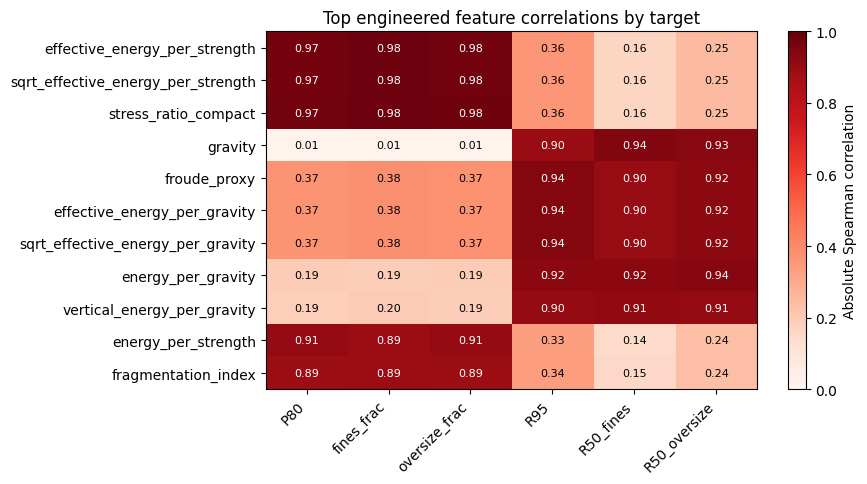

In [9]:
plt.figure(figsize=(9, max(4, 0.45 * len(top_corr_matrix))))

plt.imshow(
    top_corr_matrix.values,
    cmap="Reds",
    vmin=0,
    vmax=1,
    aspect="auto"
)

plt.xticks(
    range(len(top_corr_matrix.columns)),
    top_corr_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(top_corr_matrix.index)),
    top_corr_matrix.index
)

for i in range(top_corr_matrix.shape[0]):
    for j in range(top_corr_matrix.shape[1]):
        val = top_corr_matrix.iloc[i, j]
        text_color = "white" if val >= 0.60 else "black"
        plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=text_color)

plt.colorbar(label="Absolute Spearman correlation")
plt.title("Top engineered feature correlations by target")
plt.tight_layout()
plt.show()

### Feature-target correlation insight

The compact correlation view confirms two main patterns.

Fragmentation targets are mostly associated with material and energy-transfer features. Distance targets are mostly associated with gravity-scaled features.

This supports using different feature groups for fragmentation and distance targets in the modeling pipeline.

## 10. Mutual Information Check

Correlation captures monotonic relationships. Mutual information is added as a complementary check for non-linear dependency.

Only the top features per target are displayed to keep the notebook compact.

In [10]:
mi_rows = []

for target in target_cols:
    mi = mutual_info_regression(
        X_fe_train,
        labels[target],
        random_state=42
    )
    mi_df = pd.DataFrame({
        "target": target,
        "feature": X_fe_train.columns,
        "mutual_information": mi
    }).sort_values("mutual_information", ascending=False).head(8)
    mi_rows.append(mi_df)

mi_summary = pd.concat(mi_rows, ignore_index=True)
display(mi_summary)
mi_summary.to_csv(REPORTS_DIR / "feature_engineering_top_mutual_information.csv", index=False)

,target,feature,mutual_information
0,P80,effective_energy_per_strength,1.594748
1,P80,stress_ratio_compact,1.592473
2,P80,sqrt_effective_energy_per_strength,1.587629
3,P80,fragmentation_index,1.219276
4,P80,scaled_energy,0.998152
5,P80,energy_per_strength,0.968985
6,P80,strength,0.830598
7,P80,horizontal_energy,0.820611
8,fines_frac,sqrt_effective_energy_per_strength,1.882765
9,fines_frac,effective_energy_per_strength,1.882363


## 11. Redundancy Check

Some engineered features are intentionally related. This check identifies highly redundant pairs so that feature sets can be simplified later if needed.

In [11]:
feature_corr = X_fe_train.corr(method="spearman").abs()

upper_mask = np.triu(np.ones(feature_corr.shape, dtype=bool), k=1)
redundant_pairs = []

for i, col_i in enumerate(feature_corr.columns):
    for j, col_j in enumerate(feature_corr.columns):
        if upper_mask[i, j] and feature_corr.iloc[i, j] >= 0.98:
            redundant_pairs.append({
                "feature_1": col_i,
                "feature_2": col_j,
                "abs_spearman_corr": feature_corr.iloc[i, j]
            })

redundancy_df = pd.DataFrame(redundant_pairs).sort_values("abs_spearman_corr", ascending=False)

print("Highly redundant feature pairs:", len(redundancy_df))
display(redundancy_df.head(20))
redundancy_df.to_csv(REPORTS_DIR / "feature_engineering_redundant_pairs.csv", index=False)

Highly redundant feature pairs: 35


,feature_1,feature_2,abs_spearman_corr
0,energy,log_energy,1.0
1,angle_rad,sin_angle,1.0
2,angle_rad,cos_angle,1.0
3,angle_rad,tan_angle,1.0
4,angle_rad,vertical_horizontal_ratio,1.0
8,sin_angle,cos_angle,1.0
7,effective_energy,log_effective_energy,1.0
9,sin_angle,tan_angle,1.0
10,sin_angle,vertical_horizontal_ratio,1.0
12,cos_angle,vertical_horizontal_ratio,1.0


### Redundancy insight

Some engineered features are highly correlated because they encode similar monotonic information. This is expected for transformations such as log, square root, trigonometric transformations, and gravity-scaled ratios.

These redundancies are not necessarily harmful for tree-based models, but they confirm that final feature selection should be validated empirically rather than assuming every engineered feature adds new information.

## 12. Modeling Feature Sets

The final modeling pipeline uses separate feature sets for fragmentation and distance targets.

In [12]:
raw_features = input_cols.copy()

fragmentation_features_v1 = raw_features + [
    "effective_energy", "log_effective_energy",
    "sin_angle", "cos_angle", "horizontal_energy", "vertical_energy",
    "energy_per_strength", "effective_energy_per_strength",
    "material_resistance_index", "fragmentation_index",
    "coupling_porosity", "coupling_atmosphere", "porosity_strength",
    "drag_proxy", "atmosphere_shape_energy",
    "pi_strength_proxy", "pi_atmosphere_proxy", "scaled_energy", "fragility",
    "energy_sin_angle", "momentum_proxy",
    "porosity_regime", "strength_regime", "angle_regime", "atm_regime", "regime_combo",
]

fragmentation_features_v2 = fragmentation_features_v1 + [
    "stress_ratio_compact",
    "sqrt_effective_energy_per_strength",
]

distance_features_v1 = raw_features + [
    "effective_energy", "log_effective_energy",
    "sin_angle", "cos_angle", "horizontal_energy", "vertical_energy",
    "energy_per_gravity", "effective_energy_per_gravity",
    "horizontal_energy_per_gravity", "vertical_energy_per_gravity",
    "drag_proxy", "drag_per_gravity", "atmosphere_shape_energy", "atmosphere_per_gravity",
    "pi_gravity_proxy", "pi_atmosphere_proxy", "scaled_energy", "range_proxy",
    "energy_sin_angle", "momentum_proxy",
    "porosity_regime", "strength_regime", "angle_regime", "atm_regime", "regime_combo",
]

feature_sets = {
    "fragmentation_features_v1": fragmentation_features_v1,
    "fragmentation_features_v2": fragmentation_features_v2,
    "distance_features_v1": distance_features_v1,
}

feature_set_summary = pd.DataFrame([
    {"feature_set": name, "n_features": len(cols)}
    for name, cols in feature_sets.items()
])

display(feature_set_summary)

with open(PROCESSED_DIR / "feature_sets.json", "w") as f:
    json.dump(feature_sets, f, indent=2)

feature_set_summary.to_csv(PROCESSED_DIR / "feature_sets_summary.csv", index=False)

,feature_set,n_features
0,fragmentation_features_v1,34
1,fragmentation_features_v2,36
2,distance_features_v1,33


## 13. Save Processed Data

In [13]:
X_fe_train.to_csv(PROCESSED_DIR / "X_train_engineered.csv", index=False)
X_fe_test.to_csv(PROCESSED_DIR / "X_test_engineered.csv", index=False)
labels.to_csv(PROCESSED_DIR / "y_train.csv", index=False)

print("Saved engineered train:", PROCESSED_DIR / "X_train_engineered.csv")
print("Saved engineered test:", PROCESSED_DIR / "X_test_engineered.csv")
print("Saved labels:", PROCESSED_DIR / "y_train.csv")

Saved engineered train: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/processed/X_train_engineered.csv
Saved engineered test: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/processed/X_test_engineered.csv
Saved labels: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/processed/y_train.csv


## 14. Feature Engineering Summary

The engineered features were designed from the EDA observations.

Key modeling implications:

- fragmentation targets need material-resistance and energy-transfer features;
- distance targets need gravity-scaled and range-related features;
- regime indicators help represent threshold behavior observed in the data;
- some engineered features are redundant, so final model selection should rely on validation rather than keeping every feature automatically.

The next step is to compare models using these feature groups and choose target-specific configurations.